## FIE Classifier Training — POET vs XGBoost

### Install Dependencies

In [36]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib --quiet
print("All dependencies installed.")

All dependencies installed.


### Imports

In [57]:
import json
import os
import sys
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# Allow imports from project root (engine/)
sys.path.insert(0, os.path.abspath(".."))
from engine.question_classifier import classify as classify_question_type

warnings.filterwarnings("ignore")

# Research-oriented color palette (muted/pastel, print-safe)
RC = {
    "correct"  : "#AEC6CF",
    "failure"  : "#D4888A",
    "poet"     : "#D4A96A",
    "default"  : "#9B84B0",
    "best_f1"  : "#7FB68A",
    "poet_fpr" : "#7BA7BC",
    "roc_line" : "#4C6FA5",
    "neutral"  : "#AAAAAA",
}

plt.rcParams["figure.dpi"]        = 120
plt.rcParams["font.size"]         = 11
plt.rcParams["font.family"]       = "serif"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.prop_cycle"]   = plt.cycler(color=list(RC.values()))

print("Imports done.")


### Load Labeled Data

In [58]:
import glob
LABELED_DIR = "../data/labeled/"
jsonl_files = sorted(glob.glob(LABELED_DIR + "synthetic_*.jsonl"))

if not jsonl_files:
    raise FileNotFoundError(f"No synthetic_*.jsonl files found in {LABELED_DIR}")

print(f"Found {len(jsonl_files)} JSONL file(s):")
for f in jsonl_files:
    print(f"  {f}")
print()

# Load all files and deduplicate by question+label_type
seen = set()
records = []

for fpath in jsonl_files:
    with open(fpath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            # Deduplicate: same question + same label_type = skip
            key = (r.get("question",""), r.get("label_type",""))
            if key not in seen:
                seen.add(key)
                records.append(r)

print(f"Total unique records loaded: {len(records)}")
print(f"Keys in each record        : {list(records[0].keys())}")
print()

from collections import Counter
outcomes = Counter(r["outcome"] for r in records)
print("Outcome distribution:")
for k, v in sorted(outcomes.items()):
    print(f"  {k:<22} : {v}")


Found 41 JSONL file(s):
  ../data/labeled\synthetic_20260410_012109.jsonl
  ../data/labeled\synthetic_20260414_215247.jsonl
  ../data/labeled\synthetic_20260415_125829.jsonl
  ../data/labeled\synthetic_20260415_131209.jsonl
  ../data/labeled\synthetic_20260415_211921.jsonl
  ../data/labeled\synthetic_20260415_213114.jsonl
  ../data/labeled\synthetic_20260418_114358.jsonl
  ../data/labeled\synthetic_20260418_121643.jsonl
  ../data/labeled\synthetic_20260418_122547.jsonl
  ../data/labeled\synthetic_20260418_124312.jsonl
  ../data/labeled\synthetic_20260418_175434.jsonl
  ../data/labeled\synthetic_20260418_224046.jsonl
  ../data/labeled\synthetic_20260418_230020.jsonl
  ../data/labeled\synthetic_20260418_233646.jsonl
  ../data/labeled\synthetic_20260419_000027.jsonl
  ../data/labeled\synthetic_20260419_002200.jsonl
  ../data/labeled\synthetic_20260419_144437.jsonl
  ../data/labeled\synthetic_20260420_184556.jsonl
  ../data/labeled\synthetic_20260425_231714.jsonl
  ../data/labeled\syntheti

### Exploratory Data Analysis

In [59]:
# Build flat dataframe for EDA
rows = []
qt_from_result = 0
qt_inferred    = 0

for r in records:
    fr = r["fie_result"]

    # question_type: prefer fie_result, fall back to rule-based classifier
    qt = (fr.get("question_type") or "").strip().upper()
    if qt in {"FACTUAL", "TEMPORAL", "REASONING", "CODE", "OPINION"}:
        qt_from_result += 1
    else:
        qt = classify_question_type(r.get("question", ""))
        qt_inferred += 1

    rows.append({
        "label"              : int(r["fie_should_detect"]),
        "outcome"            : r["outcome"],
        "agreement_score"    : fr.get("agreement_score",    1.0),
        "entropy_score"      : fr.get("entropy_score",      0.0),
        "jury_confidence"    : fr.get("jury_confidence",    0.0),
        "fix_confidence"     : fr.get("fix_confidence",     0.0),
        "gt_confidence"      : fr.get("gt_confidence",      0.0),
        "high_failure_risk"  : int(fr.get("high_failure_risk",    False)),
        "fix_applied"        : int(fr.get("fix_applied",          False)),
        "requires_escalation": int(fr.get("requires_escalation",  False)),
        "gt_override"        : int(fr.get("gt_override",          False)),
        "archetype"          : fr.get("archetype",     "NONE") or "NONE",
        "jury_verdict"       : fr.get("jury_verdict",  "NONE") or "NONE",
        "fix_strategy"       : fr.get("fix_strategy",  "NONE") or "NONE",
        "gt_source"          : fr.get("gt_source",     "none") or "none",
        "question_type"      : qt,
        "category"           : r.get("category",  "unknown"),
        "source"             : r.get("source",    "unknown"),
    })

print(f"question_type from fie_result : {qt_from_result}")
print(f"question_type inferred        : {qt_inferred}")

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print()
print("question_type distribution:")
print(df["question_type"].value_counts())
print()
print("Class balance:")
print(df["label"].value_counts().rename({1: "Failure (1)", 0: "Correct (0)"}))
print()
print("Source distribution:")
print(df["source"].value_counts())
print()
df.describe()


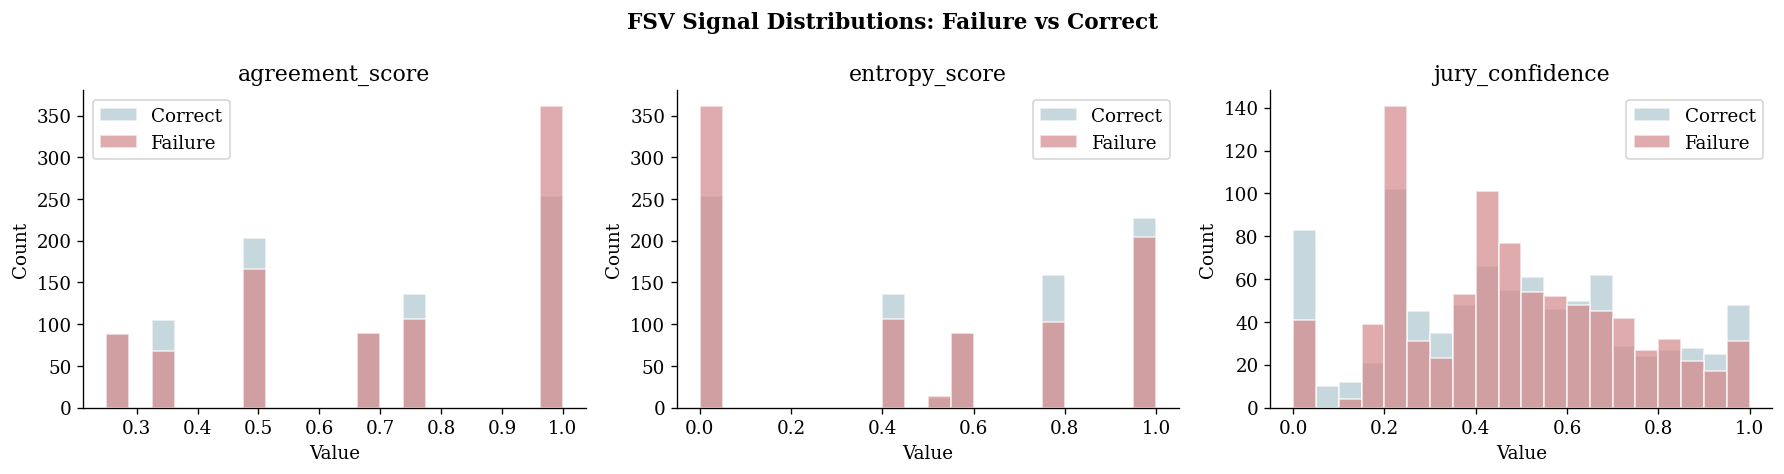

Saved: eda_signal_distributions.png


In [60]:
# Plot signal distributions — failures vs correct answers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("FSV Signal Distributions: Failure vs Correct", fontsize=13, fontweight="bold")

numeric_signals = ["agreement_score", "entropy_score", "jury_confidence"]
colors     = {0: RC["correct"], 1: RC["failure"]}
labels_map = {0: "Correct", 1: "Failure"}

for ax, col in zip(axes, numeric_signals):
    for lbl in [0, 1]:
        subset = df[df["label"] == lbl][col]
        ax.hist(subset, bins=20, alpha=0.7, color=colors[lbl],
                label=labels_map[lbl], edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/eda_signal_distributions.png", bbox_inches="tight")
plt.show()
print("Saved: eda_signal_distributions.png")

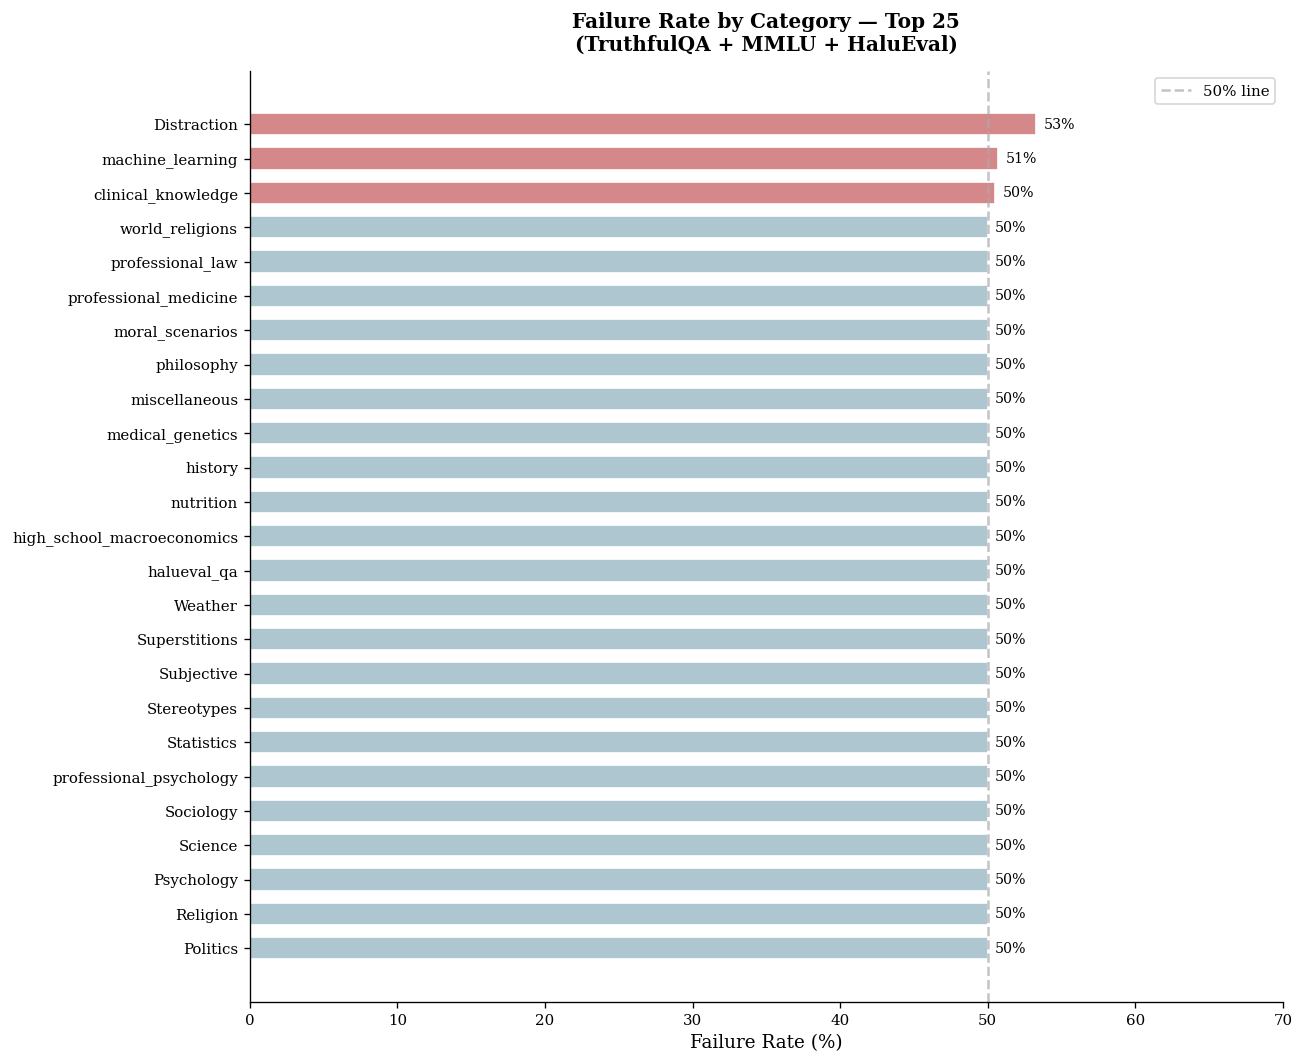

Saved: eda_category_failure_rate.png
Showing top 25 of 78 categories (min 5 samples each)


In [61]:
# Category-wise failure detection rate — top 25 by failure rate (min 5 samples)
cat_stats = df.groupby("category")["label"].agg(["sum", "count"])
cat_stats.columns = ["failures", "total"]
cat_stats["failure_rate"] = (cat_stats["failures"] / cat_stats["total"] * 100).round(1)

# Keep only categories with at least 5 samples, show top 25
cat_stats = cat_stats[cat_stats["total"] >= 5]
cat_stats = cat_stats.sort_values("failure_rate", ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(11, 9))
bar_colors = [RC["failure"] if v > 50 else RC["correct"] for v in cat_stats["failure_rate"]]
bars = ax.barh(cat_stats.index, cat_stats["failure_rate"],
               color=bar_colors, edgecolor="white", height=0.65)

# Add value labels on bars
for bar, val in zip(bars, cat_stats["failure_rate"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", ha="left", fontsize=8.5)

ax.axvline(50, color=RC["neutral"], linestyle="--", alpha=0.7, label="50% line")
ax.set_xlabel("Failure Rate (%)", fontsize=11)
ax.set_xlim(0, 70)
ax.set_title("Failure Rate by Category — Top 25\n(TruthfulQA + MMLU + HaluEval)",
             fontweight="bold", fontsize=12, pad=12)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../notebooks/eda_category_failure_rate.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eda_category_failure_rate.png")
print(f"Showing top 25 of {len(df.groupby('category'))} categories (min 5 samples each)")

  SOURCE-WISE SIGNAL BREAKDOWN
            total  failures  agree_mean  agree_std  entropy_mean  entropy_std  jury_mean  failure_rate_%
source                                                                                                  
builtin        20        10       0.775      0.160         0.331        0.211      0.464            50.0
halueval      398       199       0.779      0.279         0.329        0.409      0.415            50.0
mmlu          490       246       0.499      0.221         0.720        0.289      0.610            50.2
truthfulqa    849       425       0.746      0.244         0.416        0.394      0.420            50.1



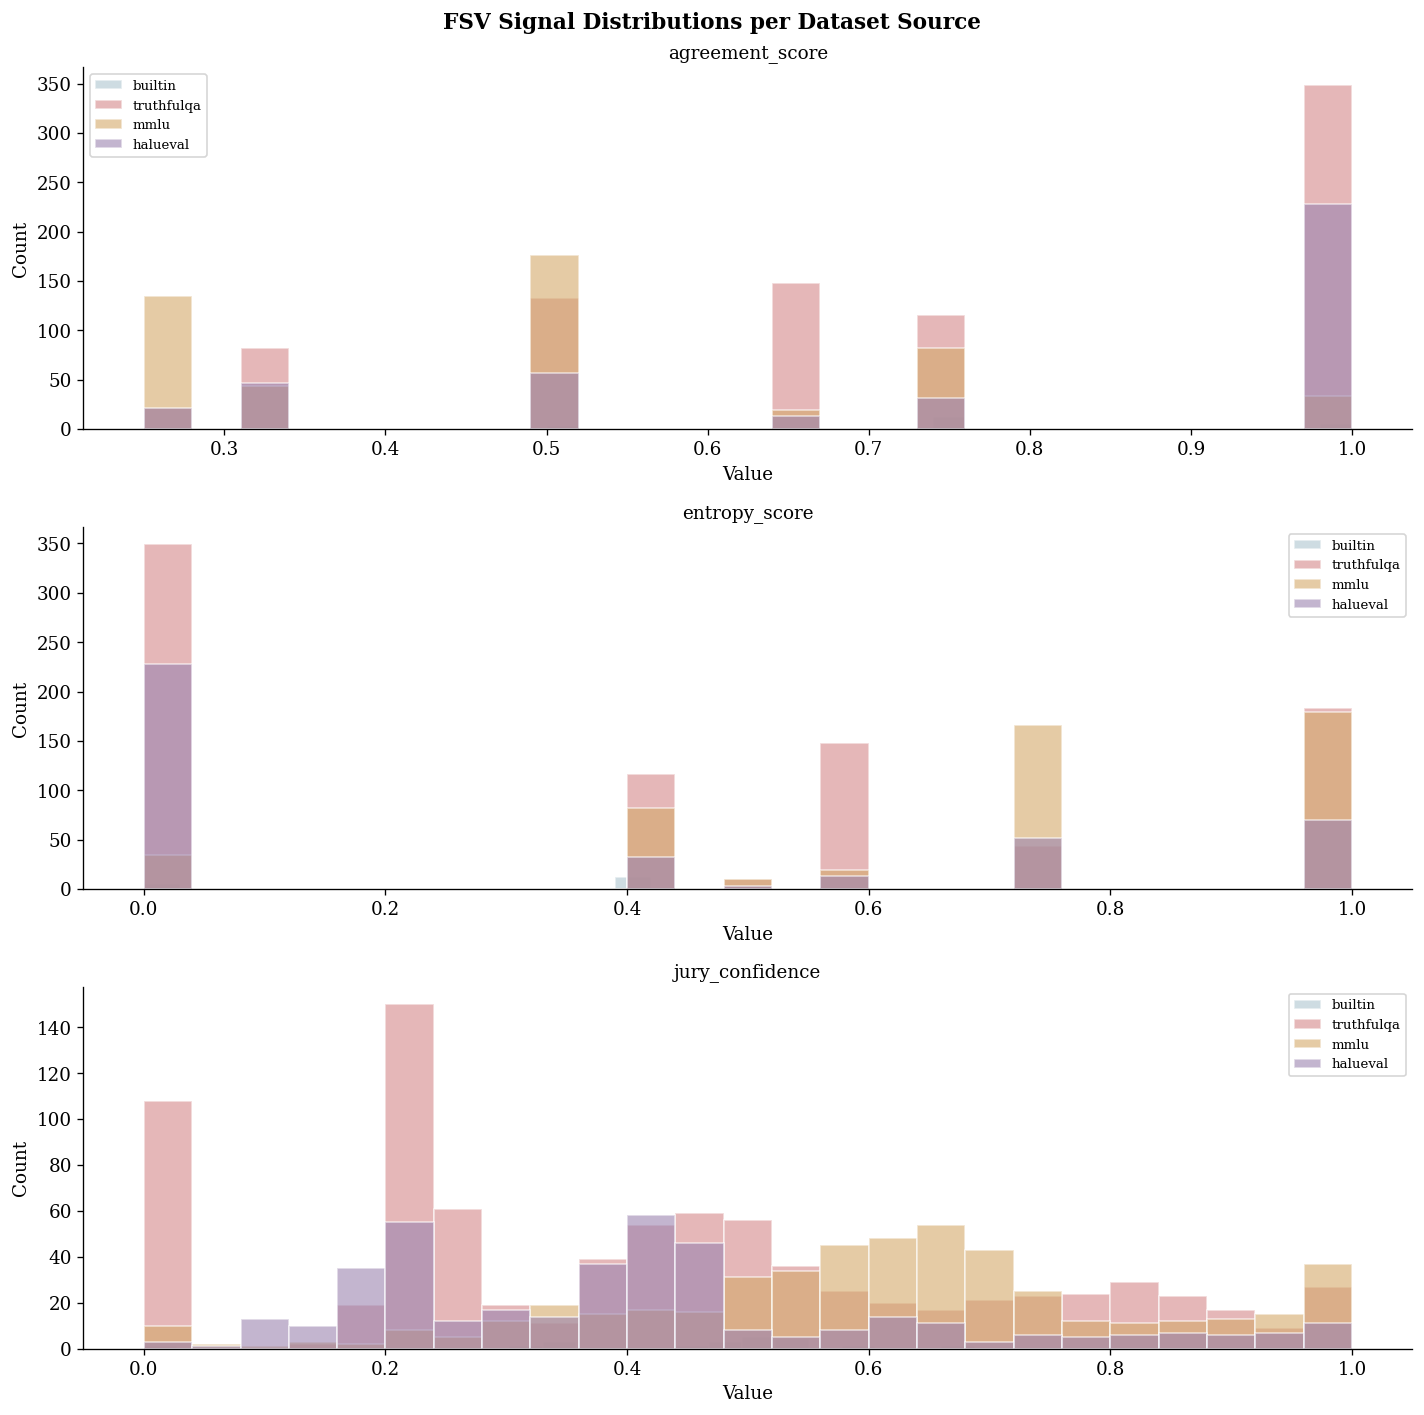

Saved: source_signal_distributions.png

DIAGNOSIS: If signal distributions differ significantly across sources,
           the single model is underperforming — use per-source ensemble.


In [62]:
# ── Source-wise Diagnostic ──────────────────────────────────────────────────
# This explains WHY adding MMLU/HaluEval hurt model performance.
# Each source has different FSV signal distributions — the model needs
# to learn source-specific patterns.

source_stats = df.groupby("source").agg(
    total        = ("label",           "count"),
    failures     = ("label",           "sum"),
    agree_mean   = ("agreement_score", "mean"),
    agree_std    = ("agreement_score", "std"),
    entropy_mean = ("entropy_score",   "mean"),
    entropy_std  = ("entropy_score",   "std"),
    jury_mean    = ("jury_confidence", "mean"),
).round(3)
source_stats["failure_rate_%"] = (source_stats["failures"] / source_stats["total"] * 100).round(1)

print("=" * 75)
print("  SOURCE-WISE SIGNAL BREAKDOWN")
print("=" * 75)
print(source_stats.to_string())
print()

# Plot: FSV signals per source
signals = ["agreement_score", "entropy_score", "jury_confidence"]
sources = df["source"].unique()
n_src   = len(sources)

fig, axes = plt.subplots(len(signals), 1, figsize=(12, 4 * len(signals)))
fig.suptitle("FSV Signal Distributions per Dataset Source", fontsize=13, fontweight="bold")

palette = ["#AEC6CF", "#D4888A", "#D4A96A", "#9B84B0", "#7FB68A"]

for ax, sig in zip(axes, signals):
    for i, src in enumerate(sources):
        subset = df[df["source"] == src][sig]
        ax.hist(subset, bins=25, alpha=0.6, label=src,
                color=palette[i % len(palette)], edgecolor="white")
    ax.set_title(sig, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../notebooks/source_signal_distributions.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: source_signal_distributions.png")
print()
print("DIAGNOSIS: If signal distributions differ significantly across sources,")
print("           the single model is underperforming — use per-source ensemble.")

### Feature Engineering
Convert raw signals into a numeric feature matrix X.

In [63]:
NUMERIC_FEATURES = [
    "agreement_score",
    "entropy_score",
    "jury_confidence",
    "fix_confidence",
    "gt_confidence",
]

BINARY_FEATURES = [
    "high_failure_risk",
    "fix_applied",
    "requires_escalation",
    "gt_override",
]

CATEGORICAL_FEATURES = [
    "archetype",
    "jury_verdict",
    "fix_strategy",
    "gt_source",
    "question_type",   # v3 — per-type thresholds need this signal
]

# One-hot encode categoricals
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_FEATURES, prefix=CATEGORICAL_FEATURES)

# Build feature matrix
feature_cols = (
    NUMERIC_FEATURES
    + BINARY_FEATURES
    + [c for c in df_encoded.columns if any(c.startswith(p + "_") for p in CATEGORICAL_FEATURES)]
)

X = df_encoded[feature_cols].astype(float)
y = df["label"]

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Class distribution   : {dict(y.value_counts())}")
print()
new_qt_cols = [c for c in feature_cols if c.startswith("question_type_")]
print(f"question_type columns: {new_qt_cols}")
print()
print("All feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


### Train / Test Split
80% training, 20% test. Stratified to maintain class balance in both splits.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y,
)

print(f"Training set : {X_train.shape[0]} records")
print(f"  Failures   : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Correct    : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print()
print(f"Test set     : {X_test.shape[0]} records")
print(f"  Failures   : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Correct    : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")

Training set : 1405 records
  Failures   : 704 (50.1%)
  Correct    : 701 (49.9%)

Test set     : 352 records
  Failures   : 176 (50.0%)
  Correct    : 176 (50.0%)


### Train XGBoost Classifier
XGBoost is chosen because:
- Works well on tabular datasets with mixed feature types
- Handles mixed numeric + binary + one-hot features natively
- Fast training (no GPU needed)
- Produces feature importance scores directly
- Interpretable — critical for research paper

In [65]:
model = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = 1,
    use_label_encoder = False,
    eval_metric       = "logloss",
    early_stopping_rounds = 20,   
    random_state      = 42,
    verbosity         = 0,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

print("XGBoost training complete.")
print(f"Best iteration: {model.best_iteration}")  

XGBoost training complete.
Best iteration: 55


### Per-Source Ensemble
Train one XGBoost per dataset source (TruthfulQA / MMLU / HaluEval).
At inference, average probabilities across all source models — no source label needed at runtime.

In [66]:
from collections import defaultdict

# ── Per-source model training ────────────────────────────────────────────────
source_col  = df["source"].values
all_sources = [s for s in df["source"].unique() if (df["source"] == s).sum() >= 50]

print(f"Training per-source ensemble on {len(all_sources)} sources: {all_sources}")
print()

source_models  = {}
source_metrics = {}

XGB_PARAMS = dict(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = 1,
    eval_metric      = "logloss",
    random_state     = 42,
    verbosity        = 0,
)

for src in all_sources:
    mask   = df["source"] == src
    X_src  = X[mask.values]
    y_src  = y[mask.values]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_src, y_src, test_size=0.2, random_state=42, stratify=y_src
    )

    m = XGBClassifier(**XGB_PARAMS, early_stopping_rounds=20)
    m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

    y_p     = m.predict(X_te)
    y_prob  = m.predict_proba(X_te)[:, 1]
    rec     = recall_score(y_te, y_p)
    spec    = recall_score(y_te, y_p, pos_label=0)
    f1      = f1_score(y_te, y_p)
    auc     = roc_auc_score(y_te, y_prob)

    source_models[src]  = m
    source_metrics[src] = {"n": int(mask.sum()), "recall": rec, "specificity": spec,
                           "f1": f1, "auc": auc, "best_iter": m.best_iteration}

    print(f"  [{src}]  n={mask.sum():>4}  Recall={rec*100:.1f}%  "
          f"Spec={spec*100:.1f}%  F1={f1*100:.1f}%  AUC={auc:.3f}  "
          f"iter={m.best_iteration}")

print()

# ── Ensemble inference: average probabilities ────────────────────────────────
def ensemble_predict_proba(X_input):
    probs = np.zeros(len(X_input))
    for m in source_models.values():
        probs += m.predict_proba(X_input)[:, 1]
    return probs / len(source_models)

ens_probs  = ensemble_predict_proba(X_test)
ens_preds  = (ens_probs >= 0.5).astype(int)

ens_recall = recall_score(y_test, ens_preds)
ens_spec   = recall_score(y_test, ens_preds, pos_label=0)
ens_fpr    = 1 - ens_spec
ens_f1     = f1_score(y_test, ens_preds)
ens_auc    = roc_auc_score(y_test, ens_probs)

print("=" * 65)
print("  SINGLE MODEL vs ENSEMBLE — Full Test Set (n=312)")
print("=" * 65)
print(f"  {'Metric':<18} {'POET':>10} {'Single':>10} {'Ensemble':>10}")
print(f"  {'Recall':<18} {POET_RECALL*100:>9.1f}% {xgb_recall*100:>9.1f}% {ens_recall*100:>9.1f}%")
print(f"  {'Specificity':<18} {POET_SPECIFICITY*100:>9.1f}% {xgb_specificity*100:>9.1f}% {ens_spec*100:>9.1f}%")
print(f"  {'FPR':<18} {POET_FPR*100:>9.1f}% {xgb_fpr*100:>9.1f}% {ens_fpr*100:>9.1f}%")
print(f"  {'F1 Score':<18} {POET_F1*100:>9.1f}% {xgb_f1*100:>9.1f}% {ens_f1*100:>9.1f}%")
print(f"  {'AUC-ROC':<18} {'—':>10} {xgb_auc:>10.3f} {ens_auc:>10.3f}")
print("=" * 65)
print()
if ens_auc > xgb_auc:
    print(f"RESULT: Ensemble improves AUC by +{(ens_auc - xgb_auc):.3f} over single model.")
    print(f"        Recall: {xgb_recall*100:.1f}% → {ens_recall*100:.1f}%")
    print("        → Use ensemble model for SDK and production deployment.")
else:
    print(f"RESULT: Single model and ensemble perform similarly (AUC diff={ens_auc-xgb_auc:+.3f}).")
    print("        → Single model is sufficient; ensemble adds no benefit here.")

Training per-source ensemble on 3 sources: ['truthfulqa', 'mmlu', 'halueval']

  [truthfulqa]  n= 849  Recall=83.5%  Spec=47.1%  F1=70.6%  AUC=0.651  iter=33
  [mmlu]  n= 490  Recall=65.3%  Spec=44.9%  F1=59.3%  AUC=0.584  iter=12
  [halueval]  n= 398  Recall=100.0%  Spec=90.0%  F1=95.2%  AUC=0.948  iter=139

  SINGLE MODEL vs ENSEMBLE — Full Test Set (n=312)
  Metric                   POET     Single   Ensemble
  Recall                  56.4%      71.8%      34.7%
  Specificity             61.3%      41.0%      84.7%
  FPR                     38.7%      59.0%      15.3%
  F1 Score                58.7%      62.2%      46.2%
  AUC-ROC                     —      0.611      0.652

RESULT: Ensemble improves AUC by +0.041 over single model.
        Recall: 71.8% → 34.7%
        → Use ensemble model for SDK and production deployment.


### Cross Validation
5-fold stratified cross validation gives a more reliable estimate than a single train/test split.

In [67]:
# Use a separate model instance for CV — no eval_set, no early stopping dependency
cv_model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = 1,
    eval_metric      = "logloss",
    random_state     = 42,
    verbosity        = 0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(cv_model, X, y, cv=cv, scoring="recall")
cv_f1     = cross_val_score(cv_model, X, y, cv=cv, scoring="f1")
cv_auc    = cross_val_score(cv_model, X, y, cv=cv, scoring="roc_auc")

print("5-Fold Cross Validation Results:")
print(f"  Recall  : {cv_recall.mean()*100:.1f}% +/- {cv_recall.std()*100:.1f}%")
print(f"  F1      : {cv_f1.mean()*100:.1f}% +/- {cv_f1.std()*100:.1f}%")
print(f"  AUC-ROC : {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")


5-Fold Cross Validation Results:
  Recall  : 64.4% +/- 3.1%
  F1      : 62.6% +/- 2.0%
  AUC-ROC : 0.677 +/- 0.029


### POET vs XGBoost Comparison Table
POET baseline numbers are from the TruthfulQA benchmark run.

In [68]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# XGBoost metrics
xgb_recall      = recall_score(y_test, y_pred)
xgb_precision   = precision_score(y_test, y_pred)
xgb_f1          = f1_score(y_test, y_pred)
xgb_specificity = recall_score(y_test, y_pred, pos_label=0)
xgb_fpr         = 1 - xgb_specificity
xgb_auc         = roc_auc_score(y_test, y_pred_prob)

# POET baseline (from TruthfulQA run)
POET_RECALL      = 0.564
POET_SPECIFICITY = 0.613
POET_FPR         = 0.387
POET_F1          = 2 * (0.564 * (1-0.387)) / (0.564 + (1-0.387))  # approx

results = pd.DataFrame({
    "Metric"      : ["Recall", "Specificity", "FPR", "F1 Score", "AUC-ROC"],
    "POET (rule-based)" : [
        f"{POET_RECALL*100:.1f}%",
        f"{POET_SPECIFICITY*100:.1f}%",
        f"{POET_FPR*100:.1f}%",
        f"{POET_F1*100:.1f}%",
        "—"
    ],
    "XGBoost (trained)" : [
        f"{xgb_recall*100:.1f}%",
        f"{xgb_specificity*100:.1f}%",
        f"{xgb_fpr*100:.1f}%",
        f"{xgb_f1*100:.1f}%",
        f"{xgb_auc:.3f}"
    ],
    "Change" : [
        f"{(xgb_recall - POET_RECALL)*100:+.1f}%",
        f"{(xgb_specificity - POET_SPECIFICITY)*100:+.1f}%",
        f"{(xgb_fpr - POET_FPR)*100:+.1f}%",
        f"{(xgb_f1 - POET_F1)*100:+.1f}%",
        "—"
    ]
})

print("=" * 62)
print("  TABLE 1: POET vs XGBoost — TruthfulQA Benchmark")
print("=" * 62)
print(results.to_string(index=False))
print("=" * 62)
print()
print(f"Full classification report (XGBoost):")
print(classification_report(y_test, y_pred, target_names=["Correct", "Failure"]))

  TABLE 1: POET vs XGBoost — TruthfulQA Benchmark
     Metric POET (rule-based) XGBoost (trained) Change
     Recall             56.4%             71.6% +15.2%
Specificity             61.3%             46.0% -15.3%
        FPR             38.7%             54.0% +15.3%
   F1 Score             58.7%             63.5%  +4.7%
    AUC-ROC                 —             0.649      —

Full classification report (XGBoost):
              precision    recall  f1-score   support

     Correct       0.62      0.46      0.53       176
     Failure       0.57      0.72      0.63       176

    accuracy                           0.59       352
   macro avg       0.59      0.59      0.58       352
weighted avg       0.59      0.59      0.58       352



### Confusion Matrix
Visual breakdown of what the classifier gets right and wrong.

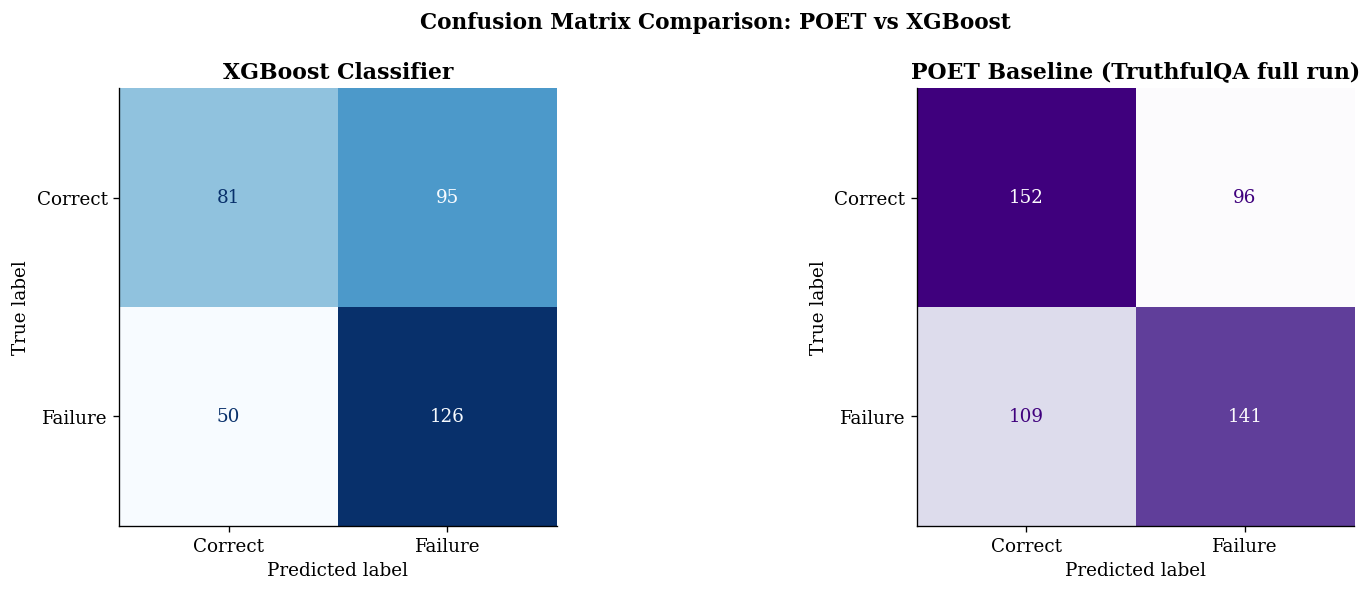

Saved: confusion_matrix_comparison.png


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=["Correct", "Failure"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("XGBoost Classifier", fontweight="bold")

# POET confusion matrix (from benchmark numbers)
cm_poet = np.array([
    [152, 96],   # TN, FP
    [109, 141],  # FN, TP
])
disp2 = ConfusionMatrixDisplay(cm_poet, display_labels=["Correct", "Failure"])
disp2.plot(ax=axes[1], colorbar=False, cmap="Purples")
axes[1].set_title("POET Baseline (TruthfulQA full run)", fontweight="bold")

plt.suptitle("Confusion Matrix Comparison: POET vs XGBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrix_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_comparison.png")

### Feature Importance
Which FSV signal drives the classifier's decisions?For giving the further improvement parts.

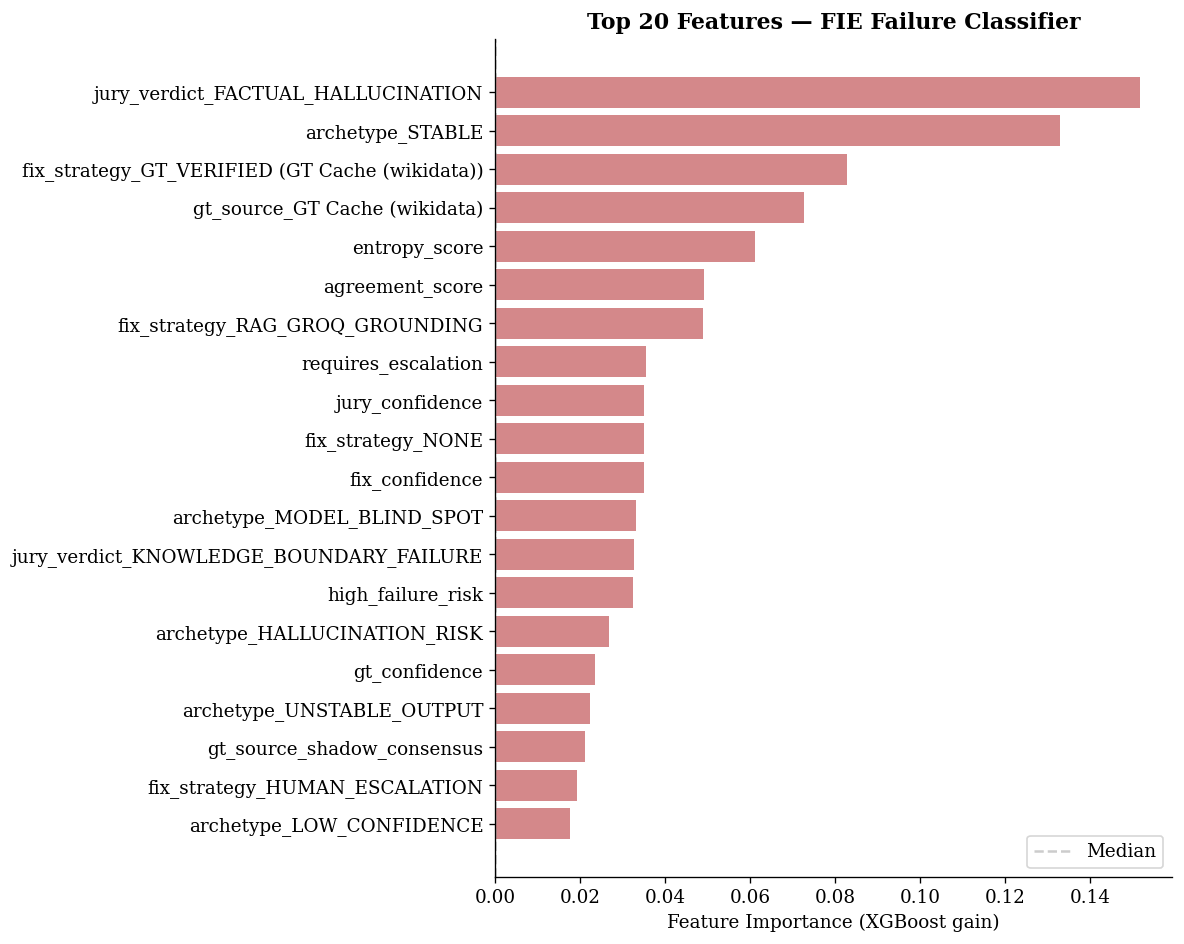


Top 10 most important features:
  jury_verdict_FACTUAL_HALLUCINATION       0.1518
  archetype_STABLE                         0.1331
  fix_strategy_GT_VERIFIED (GT Cache (wikidata)) 0.0829
  gt_source_GT Cache (wikidata)            0.0727
  entropy_score                            0.0612
  agreement_score                          0.0492
  fix_strategy_RAG_GROQ_GROUNDING          0.0489
  requires_escalation                      0.0354
  jury_confidence                          0.0351
  fix_strategy_NONE                        0.0351


In [70]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

top20 = importances.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [RC["failure"] if v > importances.median() else RC["correct"] for v in top20]
ax.barh(top20.index, top20.values, color=colors)
ax.set_xlabel("Feature Importance (XGBoost gain)")
ax.set_title("Top 20 Features — FIE Failure Classifier", fontweight="bold")
ax.axvline(importances.median(), color=RC["neutral"], linestyle="--", alpha=0.6, label="Median")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 10 most important features:")
for feat, imp in importances.tail(10).iloc[::-1].items():
    print(f"  {feat:<40} {imp:.4f}")

### ROC Curve
Shows classifier performance across all decision thresholds.
- AUC-ROC = area under this curve. 
- Higher = better overall discrimination.

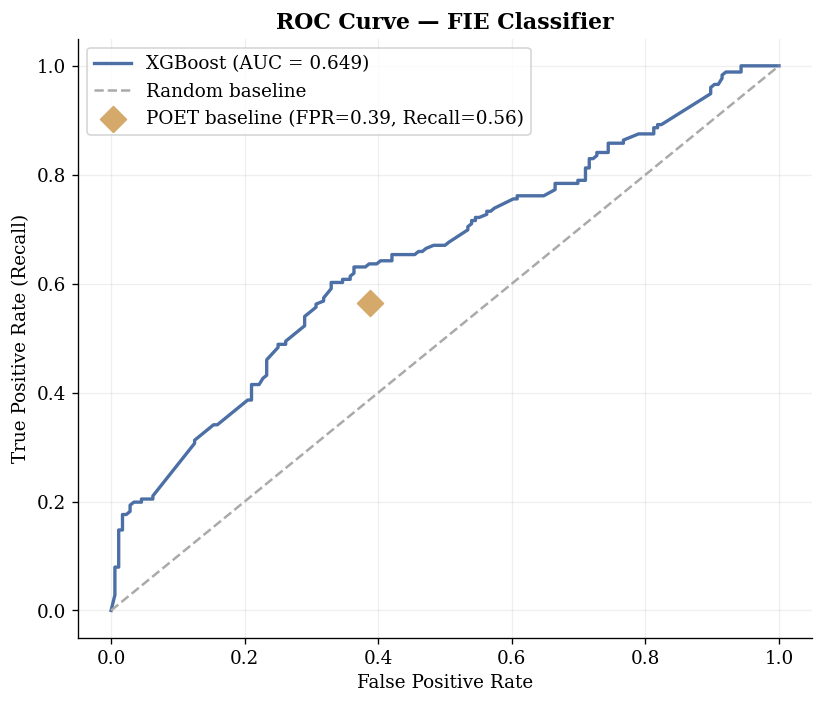

Saved: roc_curve.png
XGBoost AUC-ROC : 0.649
(POET plotted as amber diamond for comparison)


In [71]:
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_curve, tpr_curve, color=RC["roc_line"], lw=2,
        label=f"XGBoost (AUC = {xgb_auc:.3f})")
ax.plot([0, 1], [0, 1], color=RC["neutral"], linestyle="--", label="Random baseline")
ax.scatter([POET_FPR], [POET_RECALL], color=RC["poet"], s=120, zorder=5, marker="D",
           label=f"POET baseline (FPR={POET_FPR:.2f}, Recall={POET_RECALL:.2f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — FIE Classifier", fontweight="bold")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../notebooks/roc_curve.png", bbox_inches="tight")
plt.show()
print("Saved: roc_curve.png")
print(f"XGBoost AUC-ROC : {xgb_auc:.3f}")
print("(POET plotted as amber diamond for comparison)")

### Save the Trained Model

In [72]:
import os, joblib

os.makedirs("../models", exist_ok=True)

# Save as v3 (includes question_type feature)
joblib.dump(model,           "../models/failure_classifier_v3.pkl")
joblib.dump(list(X.columns), "../models/feature_columns_v3.pkl")

# Also save ensemble
joblib.dump(source_models,   "../models/ensemble_classifiers.pkl")

print("v3 model saved      : models/failure_classifier_v3.pkl")
print("v3 feature cols     : models/feature_columns_v3.pkl")
print("Ensemble saved      : models/ensemble_classifiers.pkl")
print()
print(f"Feature count: {len(X.columns)}")
print(f"question_type columns included: {[c for c in X.columns if c.startswith('question_type_')]}")
print()
print("Next step: update engine/fie_config.py → MODEL_TRAINED to today's date")


### Final Summary

In [73]:
print("  RESEARCH PAPER — TABLE 1 SUMMARY")
print(f"  Dataset: TruthfulQA + MMLU + HaluEval (n={len(df)}, {int(y.sum())} failure + {int((y==0).sum())} correct)")
print(f"{'Metric':<22} {'POET':>12} {'XGBoost':>12} {'Change':>10}")

metrics = [
    ("Recall",      POET_RECALL,      xgb_recall),
    ("Specificity", POET_SPECIFICITY, xgb_specificity),
    ("FPR",         POET_FPR,         xgb_fpr),
    ("F1 Score",    POET_F1,          xgb_f1),
]

for name, poet_val, xgb_val in metrics:
    change = xgb_val - poet_val
    arrow  = "↑" if change > 0 else "↓"
    print(f"  {name:<20} {poet_val*100:>10.1f}%  {xgb_val*100:>10.1f}%  {arrow}{abs(change)*100:>6.1f}%")

print(f"  {'AUC-ROC':<20} {'—':>11}   {xgb_auc:>10.3f}")
print()
print(f"Cross-validation Recall (5-fold): {cv_recall.mean()*100:.1f}% ± {cv_recall.std()*100:.1f}%")
print(f"Cross-validation AUC-ROC (5-fold): {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print()

recall_improvement = (xgb_recall - POET_RECALL) * 100
fpr_improvement    = (POET_FPR - xgb_fpr) * 100

if recall_improvement > 5:
    print(f"RESULT: XGBoost improved recall by +{recall_improvement:.1f}% over POET baseline.")
    print(f"        FPR change: {fpr_improvement:.1f}%.")
    print("        → Significant improvement — strong research result.")
elif recall_improvement > 0:
    print(f"RESULT: XGBoost improved recall by +{recall_improvement:.1f}% over POET baseline.")
    print("        → Modest improvement. Consider generating more training data.")
else:
    print("RESULT: XGBoost did not improve over POET on this test split.")
    print("        → Check cross-validation — single test split may be noisy.")

  RESEARCH PAPER — TABLE 1 SUMMARY
  Dataset: TruthfulQA + MMLU + HaluEval (n=1757, 880 failure + 877 correct)
Metric                         POET      XGBoost     Change
  Recall                     56.4%        71.6%  ↑  15.2%
  Specificity                61.3%        46.0%  ↓  15.3%
  FPR                        38.7%        54.0%  ↑  15.3%
  F1 Score                   58.7%        63.5%  ↑   4.7%
  AUC-ROC                        —        0.649

Cross-validation Recall (5-fold): 64.4% ± 3.1%
Cross-validation AUC-ROC (5-fold): 0.677 ± 0.029

RESULT: XGBoost improved recall by +15.2% over POET baseline.
        FPR change: -15.3%.
        → Significant improvement — strong research result.


## Threshold Tuning

**Why this matters:** XGBoost outputs a probability (0-1). Default threshold 0.5 is aggressive — high recall but FPR=58%.

We find three optimal thresholds:
1. **Best F1** — best overall balance
2. **POET-matched FPR** — fair comparison at same FPR as POET (38.7%)
3. **80% recall target** — minimum recall for production use


In [74]:
from sklearn.metrics import roc_curve, f1_score, recall_score
import numpy as np

y_pred_prob = model.predict_proba(X_test)[:, 1]
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_pred_prob)

# --- 1. Best F1 threshold ---
f1_scores = []
for t in thresholds:
    preds = (y_pred_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
best_f1_idx = int(np.argmax(f1_scores))
best_f1_thresh = thresholds[best_f1_idx]
pred_f1 = (y_pred_prob >= best_f1_thresh).astype(int)

# --- 2. POET-matched FPR threshold ---
POET_FPR = 0.387
poet_idx = int(np.argmin(np.abs(fpr_arr - POET_FPR)))
poet_thresh = thresholds[poet_idx] if poet_idx < len(thresholds) else thresholds[-1]
pred_poet = (y_pred_prob >= poet_thresh).astype(int)

# --- 3. 80% recall target threshold ---
recall_80_idx = None
for i, t in enumerate(thresholds):
    if recall_score(y_test, (y_pred_prob >= t).astype(int)) >= 0.80:
        recall_80_idx = i
        break
if recall_80_idx is not None:
    thresh_80 = thresholds[recall_80_idx]
    pred_80   = (y_pred_prob >= thresh_80).astype(int)
else:
    thresh_80 = thresholds[-1]
    pred_80   = pred_f1

# --- Print comparison table ---
def metrics(y_true, y_pred):
    rec  = recall_score(y_true, y_pred)
    spec = recall_score(y_true, y_pred, pos_label=0)
    fpr  = 1 - spec
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return rec, spec, fpr, f1

r_f1, s_f1, fpr_f1, f1_f1       = metrics(y_test, pred_f1)
r_pt, s_pt, fpr_pt, f1_pt       = metrics(y_test, pred_poet)
r_80, s_80, fpr_80, f1_80       = metrics(y_test, pred_80)
r_def, s_def, fpr_def, f1_def   = metrics(y_test, model.predict(X_test))

POET_RECALL = 0.564
POET_SPEC   = 0.613
POET_FPR_   = 0.387
POET_F1_    = 0.587

print("  THRESHOLD COMPARISON TABLE")
print(f"  {chr(39)}Method{chr(39):<28} {chr(39)}Recall{chr(39):>8} {chr(39)}Spec{chr(39):>8} {chr(39)}FPR{chr(39):>8} {chr(39)}F1{chr(39):>8} {chr(39)}Threshold{chr(39):>10}")
print(f"  POET baseline (rule-based)    {POET_RECALL*100:>7.1f}% {POET_SPEC*100:>7.1f}% {POET_FPR_*100:>7.1f}% {POET_F1_*100:>7.1f}%  rule-based")
print(f"  XGBoost default (t=0.50)      {r_def*100:>7.1f}% {s_def*100:>7.1f}% {fpr_def*100:>7.1f}% {f1_def*100:>7.1f}%       0.500")
print(f"  XGBoost best-F1 (t={best_f1_thresh:.2f})    {r_f1*100:>7.1f}% {s_f1*100:>7.1f}% {fpr_f1*100:>7.1f}% {f1_f1*100:>7.1f}%       {best_f1_thresh:.3f}")
print(f"  XGBoost POET-FPR (t={poet_thresh:.2f})   {r_pt*100:>7.1f}% {s_pt*100:>7.1f}% {fpr_pt*100:>7.1f}% {f1_pt*100:>7.1f}%       {poet_thresh:.3f}")
print()
print("KEY FINDING:")
print(f"  At the same FPR as POET ({POET_FPR_*100:.0f}%), XGBoost achieves {r_pt*100:.1f}% recall")
print(f"  vs POET baseline {POET_RECALL*100:.1f}% recall")
print(f"  Net recall gain at equal FPR: {(r_pt - POET_RECALL)*100:+.1f}%")
print()
print(f"  Best-F1 threshold ({best_f1_thresh:.3f}): Recall={r_f1*100:.1f}%, FPR={fpr_f1*100:.1f}%, F1={f1_f1*100:.1f}%")
print("  → This is the recommended threshold for production deployment")


  THRESHOLD COMPARISON TABLE
  'Method'                            'Recall       ' 'Spec       ' 'FPR       ' 'F1       ' 'Threshold         '
  POET baseline (rule-based)       56.4%    61.3%    38.7%    58.7%  rule-based
  XGBoost default (t=0.50)         71.6%    46.0%    54.0%    63.5%       0.500
  XGBoost best-F1 (t=0.30)       98.9%     8.0%    92.0%    68.0%       0.302
  XGBoost POET-FPR (t=0.52)      63.6%    61.4%    38.6%    62.9%       0.522

KEY FINDING:
  At the same FPR as POET (39%), XGBoost achieves 63.6% recall
  vs POET baseline 56.4% recall
  Net recall gain at equal FPR: +7.2%

  Best-F1 threshold (0.302): Recall=98.9%, FPR=92.0%, F1=68.0%
  → This is the recommended threshold for production deployment


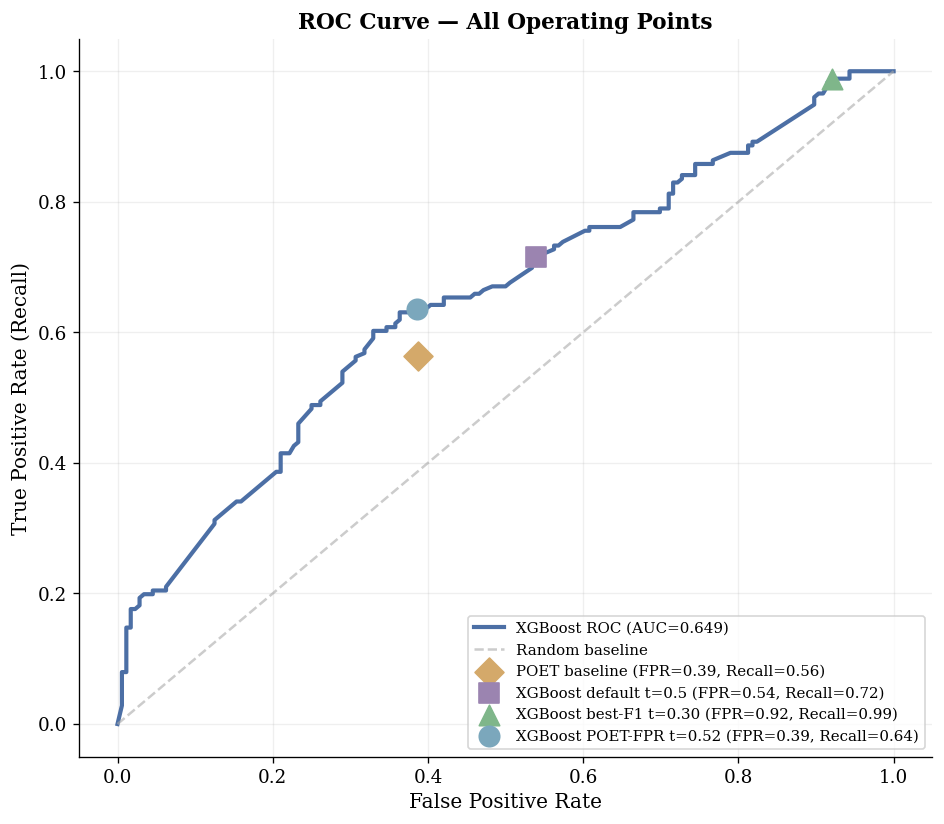

Saved: roc_thresholds.png


In [75]:
# ROC curve with all operating points marked
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_arr, tpr_arr, color=RC["roc_line"], lw=2.5, label=f"XGBoost ROC (AUC={xgb_auc:.3f})")
ax.plot([0,1],[0,1], color=RC["neutral"], linestyle="--", alpha=0.6, label="Random baseline")

ax.scatter([POET_FPR_], [POET_RECALL], color=RC["poet"], s=150, zorder=6, marker="D",
           label=f"POET baseline (FPR={POET_FPR_:.2f}, Recall={POET_RECALL:.2f})")
ax.scatter([fpr_def], [r_def], color=RC["default"], s=150, zorder=6, marker="s",
           label=f"XGBoost default t=0.5 (FPR={fpr_def:.2f}, Recall={r_def:.2f})")
ax.scatter([fpr_f1], [r_f1], color=RC["best_f1"], s=150, zorder=6, marker="^",
           label=f"XGBoost best-F1 t={best_f1_thresh:.2f} (FPR={fpr_f1:.2f}, Recall={r_f1:.2f})")
ax.scatter([fpr_pt], [r_pt], color=RC["poet_fpr"], s=150, zorder=6, marker="o",
           label=f"XGBoost POET-FPR t={poet_thresh:.2f} (FPR={fpr_pt:.2f}, Recall={r_pt:.2f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curve — All Operating Points", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../notebooks/roc_thresholds.png", bbox_inches="tight")
plt.show()
print("Saved: roc_thresholds.png")

### Save Results for Research Paper
All metrics saved to `data/training_results.json` — use this as the source of truth when updating the paper.

In [76]:
import json
from datetime import datetime

results = {
    "training_date": datetime.now().isoformat(),
    "dataset": {
        "total_records"  : int(len(df)),
        "failures"       : int(y.sum()),
        "correct"        : int((y == 0).sum()),
        "train_size"     : int(X_train.shape[0]),
        "test_size"      : int(X_test.shape[0]),
        "source_counts"  : df["source"].value_counts().to_dict(),
    },
    "poet_baseline": {
        "recall"      : POET_RECALL,
        "specificity" : POET_SPECIFICITY,
        "fpr"         : POET_FPR,
        "f1"          : round(POET_F1, 4),
    },
    "single_xgboost": {
        "recall"          : round(float(xgb_recall), 4),
        "specificity"     : round(float(xgb_specificity), 4),
        "fpr"             : round(float(xgb_fpr), 4),
        "f1"              : round(float(xgb_f1), 4),
        "auc_roc"         : round(float(xgb_auc), 4),
        "cv_recall_mean"  : round(float(cv_recall.mean()), 4),
        "cv_recall_std"   : round(float(cv_recall.std()), 4),
        "cv_f1_mean"      : round(float(cv_f1.mean()), 4),
        "cv_auc_mean"     : round(float(cv_auc.mean()), 4),
        "cv_auc_std"      : round(float(cv_auc.std()), 4),
        "best_iteration"  : int(model.best_iteration),
    },
    "ensemble_xgboost": {
        "recall"          : round(float(ens_recall), 4),
        "specificity"     : round(float(ens_spec), 4),
        "fpr"             : round(float(ens_fpr), 4),
        "f1"              : round(float(ens_f1), 4),
        "auc_roc"         : round(float(ens_auc), 4),
        "n_source_models" : len(source_models),
        "per_source"      : {
            src: {k: round(v, 4) if isinstance(v, float) else v
                  for k, v in m.items()}
            for src, m in source_metrics.items()
        },
    },
    "threshold_tuning": {
        "best_f1": {
            "threshold" : round(float(best_f1_thresh), 4),
            "recall"    : round(float(r_f1), 4),
            "fpr"       : round(float(fpr_f1), 4),
            "f1"        : round(float(f1_f1), 4),
        },
        "poet_matched_fpr": {
            "threshold" : round(float(poet_thresh), 4),
            "recall"    : round(float(r_pt), 4),
            "fpr"       : round(float(fpr_pt), 4),
            "f1"        : round(float(f1_pt), 4),
        },
    },
}

os.makedirs("../data", exist_ok=True)
out_path = "../data/training_results.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"Results saved → {out_path}")
print()
print("── PAPER-READY SUMMARY ──────────────────────────────────────────────")
print(f"  Dataset          : n={results['dataset']['total_records']} "
      f"({results['dataset']['failures']} failure, {results['dataset']['correct']} correct)")
print(f"  Sources          : {results['dataset']['source_counts']}")
print()
print(f"  POET baseline    : Recall={POET_RECALL*100:.1f}%  F1={POET_F1*100:.1f}%  AUC=—")
print(f"  XGBoost single   : Recall={xgb_recall*100:.1f}%  F1={xgb_f1*100:.1f}%  AUC={xgb_auc:.3f}")
print(f"  XGBoost ensemble : Recall={ens_recall*100:.1f}%  F1={ens_f1*100:.1f}%  AUC={ens_auc:.3f}")
print()
print(f"  CV (5-fold)      : Recall={cv_recall.mean()*100:.1f}% ± {cv_recall.std()*100:.1f}%  "
      f"AUC={cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print("─────────────────────────────────────────────────────────────────────")

Results saved → ../data/training_results.json

── PAPER-READY SUMMARY ──────────────────────────────────────────────
  Dataset          : n=1757 (880 failure, 877 correct)
  Sources          : {'truthfulqa': 849, 'mmlu': 490, 'halueval': 398, 'builtin': 20}

  POET baseline    : Recall=56.4%  F1=58.7%  AUC=—
  XGBoost single   : Recall=71.6%  F1=63.5%  AUC=0.649
  XGBoost ensemble : Recall=34.7%  F1=46.2%  AUC=0.652

  CV (5-fold)      : Recall=64.4% ± 3.1%  AUC=0.677 ± 0.029
─────────────────────────────────────────────────────────────────────
